In [1]:
!pip install statsmodels xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_excel("gold_return_prediction.xlsx")

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [5]:
df["Target_Return"] = df["DoD_Change_INR_10g_%"]

In [6]:
df["Gold_USD_lag_1"] = df["Gold_USD_oz"].shift(1)
df["USD_INR_lag_1"] = df["USD_INR"].shift(1)
df["VIX_lag_1"] = df["VIX"].shift(1)
df["NIFTY_lag_1"] = df["NIFTY_50"].shift(1)

# Gold
df["Gold_USD_lag_2"] = df["Gold_USD_oz"].shift(2)
df["Gold_USD_lag_7"] = df["Gold_USD_oz"].shift(7)

# USDINR
df["USD_INR_lag_2"] = df["USD_INR"].shift(2)

# VIX
df["VIX_lag_2"] = df["VIX"].shift(2)

# NIFTY
df["NIFTY_lag_2"] = df["NIFTY_50"].shift(2)





In [7]:
# Trend
df["gold_ma_7"] = df["Gold_USD_oz"].rolling(7).mean()
df["gold_ma_14"] = df["Gold_USD_oz"].rolling(14).mean()

# Volatility
df["gold_vol_7"] = df["Gold_USD_oz"].rolling(7).std()

# Momentum
df["gold_momentum_7"] = df["Gold_USD_oz"] - df["Gold_USD_oz"].shift(7)

In [8]:
df["gold_usd_x_inr"] = df["Gold_USD_lag_1"] * df["USD_INR_lag_1"]
df["vix_x_nifty"] = df["VIX_DoD%"] * df["NIFTY_50_%DoD"]

In [9]:
df = df.dropna().reset_index(drop=True)

In [10]:
features = [
    "Gold_USD_lag_1", "Gold_USD_lag_2", "Gold_USD_lag_7",
    "USD_INR_lag_1", "USD_INR_lag_2",
    "VIX_lag_1", "VIX_lag_2",
    "NIFTY_lag_1", "NIFTY_lag_2",

    "gold_ma_7", "gold_ma_14",
    "gold_vol_7", "gold_momentum_7",

    "gold_usd_x_inr", "vix_x_nifty",

    "VIX_DoD%",
    "Crude_Oil_%DoD",
    "NIFTY_50_%DoD",
    "US_10Y_Treasury_Yield_%",
    "India_BondYeilds"
]

X = df[features]
y = df["Target_Return"]

In [11]:
split = int(len(df) * 0.85)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [12]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX MODEL

In [13]:
sarimax_pred = sarimax_fit.predict(
    start=len(X_train),
    end=len(X_train) + len(X_test) - 1,
    exog=X_test
)

In [14]:
sarimax_train_pred = sarimax_fit.predict(
    start=0,
    end=len(X_train) - 1,
    exog=X_train
)

XG BOOST

In [15]:
residuals = y_train - sarimax_train_pred

In [16]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, residuals)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
residual_pred = xgb_model.predict(X_test)

Combining both the predictions

In [18]:
final_pred = sarimax_pred + residual_pred

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, final_pred))
mae = np.mean(np.abs(y_test - final_pred))

print("Hybrid RMSE:", rmse)
print("Hybrid MAE:", mae)

Hybrid RMSE: 0.007863214279456257
Hybrid MAE: 0.006985952740940365


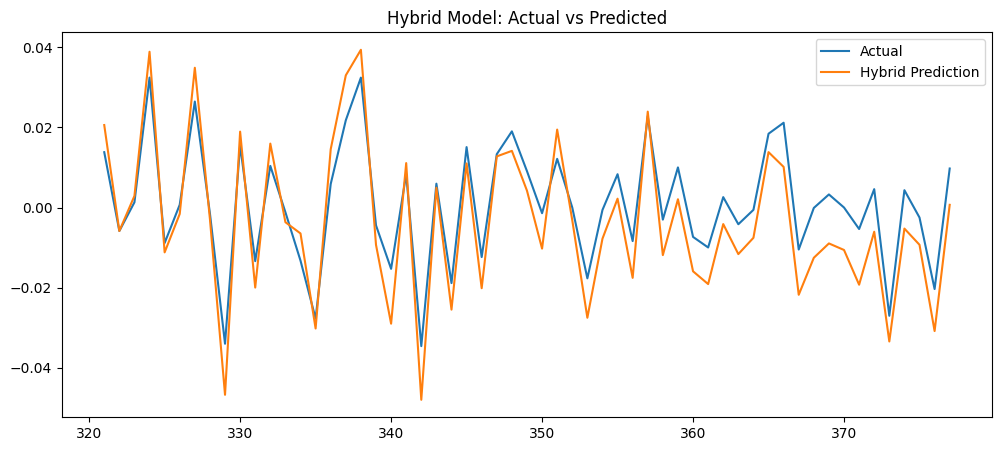

In [23]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, final_pred, label="Hybrid Prediction")

plt.legend()
plt.title("Hybrid Model: Actual vs Predicted")
plt.show()

In [24]:
print(len(y_test), len(final_pred))

57 57


In [25]:
print(y_test.head())
print(final_pred[:5])

321    0.013813
322   -0.005862
323    0.001302
324    0.032438
325   -0.008864
Name: Target_Return, dtype: float64
321    0.020588
322   -0.005860
323    0.002899
324    0.038885
325   -0.011197
Name: predicted_mean, dtype: float64


Comparing the models